In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df1= pd.read_csv("/content/drive/MyDrive/gauri ka folder/SP 500 ESG Risk Ratings.csv")
df1.head()

,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,Controversy Level,Controversy Score,ESG Risk Percentile,ESG Risk Level
0,ENPH,"Enphase Energy, Inc.","47281 Bayside Parkway\nFremont, CA 94538\nUnit...",Technology,Solar,"3,157","Enphase Energy, Inc., together with its subsid...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EMN,Eastman Chemical Company,"200 South Wilcox Drive\nKingsport, TN 37662\nU...",Basic Materials,Specialty Chemicals,"14,000",Eastman Chemical Company operates as a special...,25.3,12.8,6.6,5.8,Moderate Controversy Level,2.0,50th percentile,Medium
2,DPZ,Domino's Pizza Inc.,"30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...",Consumer Cyclical,Restaurants,"6,500","Domino's Pizza, Inc., through its subsidiaries...",29.2,10.6,6.3,12.2,Moderate Controversy Level,2.0,66th percentile,Medium
3,DAY,"Dayforce, Inc.","3311 East Old Shakopee Road\nMinneapolis, MN 5...",Technology,Software - Application,"9,084","Dayforce Inc., together with its subsidiaries,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DVA,Davita Inc.,"2000 16th Street\nDenver, CO 80202\nUnited States",Healthcare,Medical Care Facilities,"70,000",DaVita Inc. provides kidney dialysis services ...,22.6,0.1,8.4,14.1,Moderate Controversy Level,2.0,38th percentile,Medium


In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/gauri ka folder/all_stocks_5yr.csv")
df2.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [ ]:
stock_df = df2[['date', 'close', 'Name']]

stock_df.columns = ['date', 'close', 'ticker']

stock_df['date'] = pd.to_datetime(stock_df['date'])

stock_df = stock_df.sort_values(by=['ticker', 'date']).reset_index(drop=True)

print(stock_df.head())

        date  close ticker
0 2013-02-08  45.08      A
1 2013-02-11  44.60      A
2 2013-02-12  44.62      A
3 2013-02-13  44.75      A
4 2013-02-14  44.58      A


/tmp/ipython-input-701962736.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_df['date'] = pd.to_datetime(stock_df['date'])


In [ ]:
# Compute daily returns per company

stock_df['daily_return'] = stock_df.groupby('ticker')['close'].pct_change()

stock_df = stock_df.dropna().reset_index(drop=True)

print(stock_df.head(10))

        date  close ticker  daily_return
0 2013-02-11  44.60      A     -0.010648
1 2013-02-12  44.62      A      0.000448
2 2013-02-13  44.75      A      0.002913
3 2013-02-14  44.58      A     -0.003799
4 2013-02-15  42.25      A     -0.052266
5 2013-02-19  43.01      A      0.017988
6 2013-02-20  42.24      A     -0.017903
7 2013-02-21  41.63      A     -0.014441
8 2013-02-22  41.80      A      0.004084
9 2013-02-25  41.29      A     -0.012201


In [ ]:
# Compute volatility per company
volatility_df = stock_df.groupby('ticker')['daily_return'].std().reset_index()
volatility_df.columns = ['ticker', 'volatility']

# Median threshold
threshold = volatility_df['volatility'].median()

# Binary risk labeling
def risk_label_binary(v):
    if v <= threshold:
        return 0   # Low risk
    else:
        return 1   # High risk

volatility_df['risk_label'] = volatility_df['volatility'].apply(risk_label_binary)

# Human-readable labels
risk_map = {0: 'Low', 1: 'High'}
volatility_df['risk_category'] = volatility_df['risk_label'].map(risk_map)

print(volatility_df.head(10))
print(volatility_df['risk_category'].value_counts())

  ticker  volatility  risk_label risk_category
0      A    0.015482           1          High
1    AAL    0.022456           1          High
2    AAP    0.018958           1          High
3   AAPL    0.014593           1          High
4   ABBV    0.016856           1          High
5    ABC    0.013935           0           Low
6    ABT    0.012322           0           Low
7    ACN    0.011839           0           Low
8   ADBE    0.015321           1          High
9    ADI    0.014934           1          High
risk_category
Low     253
High    252
Name: count, dtype: int64


In [ ]:
df1 = df1.rename(columns={
    'Symbol': 'ticker',
    'Name': 'company',
    'Sector': 'sector',
    'Industry': 'industry',
    'Total ESG Risk score': 'esg_risk_score',
    'Environment Risk Score': 'environment_risk_score',
    'Social Risk Score': 'social_risk_score',
    'Governance Risk Score': 'governance_risk_score',
    'Controversy Level': 'controversy_level',
    'Controversy Score': 'controversy_score',
    'ESG Risk Percentile': 'esg_risk_percentile',
    'ESG Risk Level': 'esg_risk_level'
})

In [ ]:
df1 = df1[[
    'ticker',
    'company',
    'sector',
    'industry',
    'esg_risk_score',
    'environment_risk_score',
    'social_risk_score',
    'governance_risk_score',
    'controversy_level',
    'controversy_score'
]]
df1['ticker'] = df1['ticker'].astype(str).str.strip().str.upper()

In [ ]:
num_cols = [
    'esg_risk_score',
    'environment_risk_score',
    'social_risk_score',
    'governance_risk_score',
    'controversy_score'
]

for col in num_cols:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

In [ ]:
df1 = df1.dropna(subset=[
    'ticker',
    'esg_risk_score',
    'environment_risk_score',
    'social_risk_score',
    'governance_risk_score'
])

In [ ]:
volatility_df['ticker'] = volatility_df['ticker'].astype(str).str.strip().str.upper()
merged_df = pd.merge(df1, volatility_df, on='ticker', how='inner')
print(merged_df.head())
print("\nShape:", merged_df.shape)
print("\nRisk distribution:\n", merged_df['risk_category'].value_counts())

  ticker                       company             sector  \
0    EMN      Eastman Chemical Company    Basic Materials   
1    DVA                   Davita Inc.         Healthcare   
2    DRI      Darden Restaurants, Inc.  Consumer Cyclical   
3    ZTS                   Zoetis Inc.         Healthcare   
4    ZBH  Zimmer Biomet Holdings, Inc.         Healthcare   

                                   industry  esg_risk_score  \
0                       Specialty Chemicals            25.3   
1                   Medical Care Facilities            22.6   
2                               Restaurants            27.5   
3  Drug Manufacturers - Specialty & Generic            18.8   
4                           Medical Devices            26.0   

   environment_risk_score  social_risk_score  governance_risk_score  \
0                    12.8                5.8                    6.6   
1                     0.1               14.1                    8.4   
2                     7.9               1

In [ ]:
features = [
    'esg_risk_score',
    'environment_risk_score',
    'social_risk_score',
    'governance_risk_score',
    'controversy_score',
    'sector',
    'industry'
]

target = 'risk_label'

X = merged_df[features]
y = merged_df[target]

In [ ]:
from sklearn.preprocessing import LabelEncoder

X = X.copy()

cat_cols = ['sector', 'industry']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 294, number of used features: 7
[LightGBM] [Info] Start training from score -0.577634
[LightGBM] [Info] Start training from score -0.823767
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=500, num_class=3, objective='multiclass',
               random_state=42, subsample=0.8)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.581081081081081

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.64        41
           1       0.53      0.48      0.51        33

    accuracy                           0.58        74
   macro avg       0.57      0.57      0.57        74
weighted avg       0.58      0.58      0.58        74


Confusion Matrix:
 [[27 14]
 [17 16]]


In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

In [ ]:
type(shap_values)
len(shap_values)
import numpy as np
np.array(shap_values).shape
X_test.shape

(74, 7)

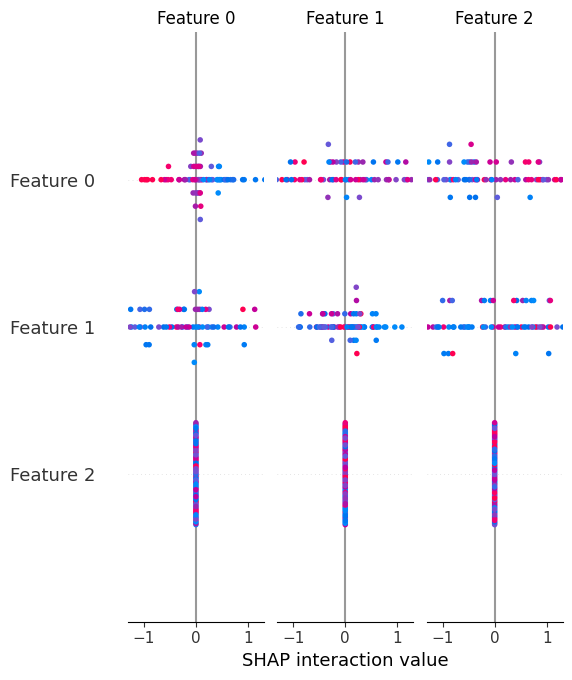

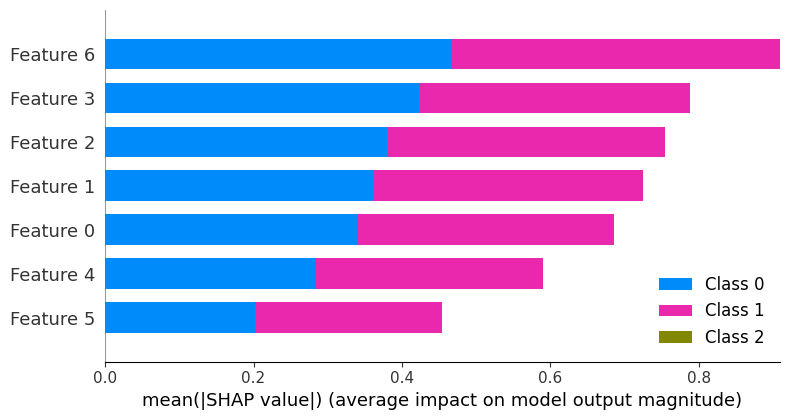

In [ ]:
X_test_np = X_test.values

shap.summary_plot(shap_values, X_test_np)
shap.summary_plot(shap_values, X_test_np, plot_type="bar")

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c78fcadfcbe3a901c1148eaf28d5c5ff5651832084d257888eebff2050798936
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

class_names = ['Low Risk', 'High Risk']

explainer_lime = LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = X_train.columns.tolist(),
    class_names = class_names,
    mode = 'classification'
)

In [ ]:
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()

# Ensure float
X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

# Replace inf/nan
X_train_lime = X_train_lime.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_lime = X_test_lime.replace([np.inf, -np.inf], np.nan).fillna(0)

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

class_names = ['Low Risk', 'High Risk']

explainer_lime = LimeTabularExplainer(
    training_data = X_train_lime.values,
    feature_names = X_train_lime.columns.tolist(),
    class_names = class_names,
    mode = 'classification',
    discretize_continuous = True,
    verbose = True
)

In [ ]:
i = np.random.randint(0, X_test_lime.shape[0])

exp = explainer_lime.explain_instance(
    X_test_lime.values[i],
    model.predict_proba,
    num_features = min(7, X_test_lime.shape[1])
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Intercept 0.4956178132770728
Prediction_local [0.54772015]
Right: 0.12963462278586835


In [ ]:
# Ensure proper sorting
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = stock_df.sort_values(['ticker', 'date'])

# Compute cumulative return per ticker
return_df = stock_df.groupby('ticker').agg(
    first_close = ('close', 'first'),
    last_close = ('close', 'last')
).reset_index()

# Cumulative return formula
return_df['cumulative_return'] = (
    (return_df['last_close'] - return_df['first_close']) / return_df['first_close']
)

print(return_df.head(10))

  ticker  first_close  last_close  cumulative_return
0      A      44.6000       68.06           0.526009
1    AAL      14.4600       51.40           2.554633
2    AAP      78.3900      109.93           0.402347
3   AAPL      68.5614      159.54           1.326965
4   ABBV      35.8500      113.62           2.169317
5    ABC      46.7600       94.22           1.014970
6    ABT      34.2600       58.67           0.712493
7    ACN      73.0700      155.15           1.123306
8   ADBE      38.6400      192.34           3.977743
9    ADI      46.0800       85.35           0.852214


In [ ]:
return_threshold = return_df['cumulative_return'].median()

# Risk labeling
def return_risk_label(r):
    if r <= return_threshold:
        return 1   # High Risk (low returns)
    else:
        return 0   # Low Risk (high returns)

return_df['return_risk_label'] = return_df['cumulative_return'].apply(return_risk_label)

risk_map = {0: 'Low', 1: 'High'}
return_df['return_risk_category'] = return_df['return_risk_label'].map(risk_map)

print(return_df.head(10))
print(return_df['return_risk_category'].value_counts())

  ticker  first_close  last_close  cumulative_return  return_risk_label  \
0      A      44.6000       68.06           0.526009                  1   
1    AAL      14.4600       51.40           2.554633                  0   
2    AAP      78.3900      109.93           0.402347                  1   
3   AAPL      68.5614      159.54           1.326965                  0   
4   ABBV      35.8500      113.62           2.169317                  0   
5    ABC      46.7600       94.22           1.014970                  0   
6    ABT      34.2600       58.67           0.712493                  0   
7    ACN      73.0700      155.15           1.123306                  0   
8   ADBE      38.6400      192.34           3.977743                  0   
9    ADI      46.0800       85.35           0.852214                  0   

  return_risk_category  
0                 High  
1                  Low  
2                 High  
3                  Low  
4                  Low  
5                  Low  

In [ ]:
# Merge volatility target
merged_df = pd.merge(df1, volatility_df[['ticker','risk_label']],
                     on='ticker', how='inner')

merged_df.rename(columns={'risk_label':'volatility_risk_label'}, inplace=True)

# Merge return target
merged_df = pd.merge(merged_df, return_df[['ticker','return_risk_label']],
                     on='ticker', how='inner')

print(merged_df.head())

  ticker                       company             sector  \
0    EMN      Eastman Chemical Company    Basic Materials   
1    DVA                   Davita Inc.         Healthcare   
2    DRI      Darden Restaurants, Inc.  Consumer Cyclical   
3    ZTS                   Zoetis Inc.         Healthcare   
4    ZBH  Zimmer Biomet Holdings, Inc.         Healthcare   

                                   industry  esg_risk_score  \
0                       Specialty Chemicals            25.3   
1                   Medical Care Facilities            22.6   
2                               Restaurants            27.5   
3  Drug Manufacturers - Specialty & Generic            18.8   
4                           Medical Devices            26.0   

   environment_risk_score  social_risk_score  governance_risk_score  \
0                    12.8                5.8                    6.6   
1                     0.1               14.1                    8.4   
2                     7.9               1

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_sector = LabelEncoder()
le_industry = LabelEncoder()

merged_df['sector_enc'] = le_sector.fit_transform(merged_df['sector'].astype(str))
merged_df['industry_enc'] = le_industry.fit_transform(merged_df['industry'].astype(str))

In [ ]:
features = [
    'esg_risk_score',
    'environment_risk_score',
    'social_risk_score',
    'governance_risk_score',
    'controversy_score',
    'sector_enc',
    'industry_enc'
]

X = merged_df[features]

y_volatility = merged_df['volatility_risk_label']
y_return = merged_df['return_risk_label']

In [ ]:
from sklearn.model_selection import train_test_split

# Volatility model split
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X, y_volatility, test_size=0.25, random_state=42, stratify=y_volatility
)

# Return model split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_return, test_size=0.25, random_state=42, stratify=y_return
)

In [ ]:
from lightgbm import LGBMClassifier

# Volatility model
model_vol = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_vol.fit(X_train_v, y_train_v)

# Return model
model_ret = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_ret.fit(X_train_r, y_train_r)

[LightGBM] [Info] Number of positive: 122, number of negative: 154
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 345
[LightGBM] [Info] Number of data points in the train set: 276, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.442029 -> initscore=-0.232932
[LightGBM] [Info] Start training from score -0.232932
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=300,
               random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Volatility evaluation
y_pred_v = model_vol.predict(X_test_v)
print("VOLATILITY MODEL")
print("Accuracy:", accuracy_score(y_test_v, y_pred_v))
print(classification_report(y_test_v, y_pred_v))
print(confusion_matrix(y_test_v, y_pred_v))

print("\n-----------------------------\n")

# Return evaluation
y_pred_r = model_ret.predict(X_test_r)
print("RETURN MODEL")
print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print(classification_report(y_test_r, y_pred_r))
print(confusion_matrix(y_test_r, y_pred_r))

VOLATILITY MODEL
Accuracy: 0.5543478260869565
              precision    recall  f1-score   support

           0       0.60      0.65      0.62        52
           1       0.49      0.42      0.45        40

    accuracy                           0.55        92
   macro avg       0.54      0.54      0.54        92
weighted avg       0.55      0.55      0.55        92

[[34 18]
 [23 17]]

-----------------------------

RETURN MODEL
Accuracy: 0.6413043478260869
              precision    recall  f1-score   support

           0       0.65      0.76      0.70        51
           1       0.62      0.49      0.55        41

    accuracy                           0.64        92
   macro avg       0.64      0.63      0.63        92
weighted avg       0.64      0.64      0.63        92

[[39 12]
 [21 20]]


In [ ]:
# Use TreeExplainer for LightGBM / tree models
explainer_vol = shap.TreeExplainer(model_vol)

# SHAP values
shap_values_vol = explainer_vol.shap_values(X_test_v)

# Convert to numpy (important for stability)
if isinstance(shap_values_vol, list):
    shap_values_vol_arr = np.array(shap_values_vol)
else:
    shap_values_vol_arr = shap_values_vol

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
explainer_ret = shap.TreeExplainer(model_ret)

shap_values_ret = explainer_ret.shap_values(X_test_r)

if isinstance(shap_values_ret, list):
    shap_values_ret_arr = np.array(shap_values_ret)
else:
    shap_values_ret_arr = shap_values_ret

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


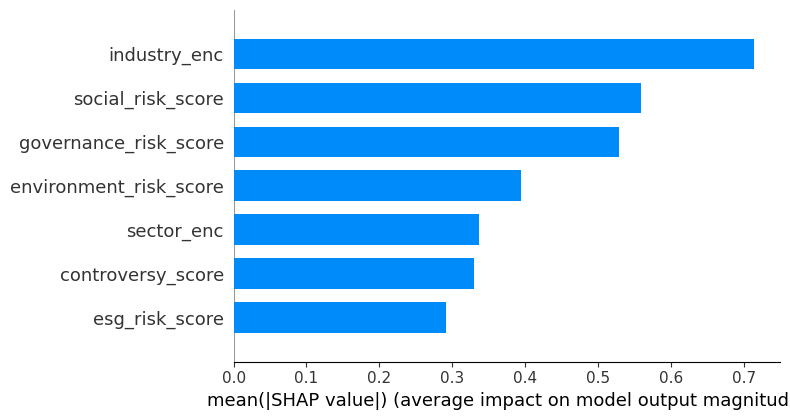

In [ ]:
shap.summary_plot(
    shap_values_vol_arr,
    X_test_v,
    plot_type="bar",
    show=True
)

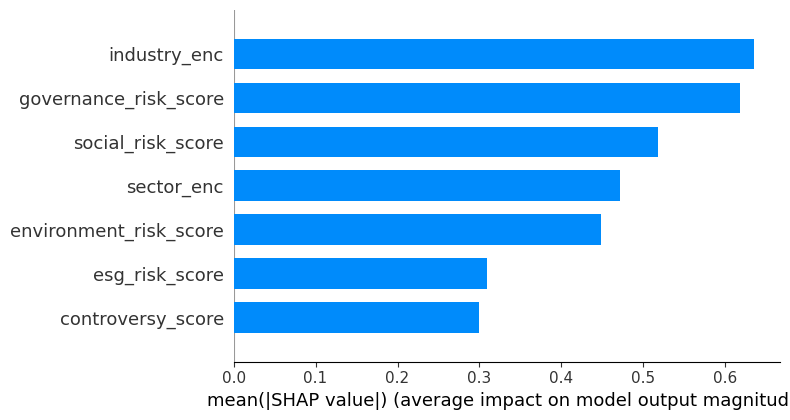

In [ ]:
shap.summary_plot(
    shap_values_ret_arr,
    X_test_r,
    plot_type="bar",
    show=True
)

In [ ]:
E_features = ['Environment Risk Score']
S_features = ['Social Risk Score']
G_features = ['Governance Risk Score']

core_esg = ['Total ESG Risk score']

In [ ]:
feature_names = X_test_v.columns.tolist()

E_idx = [feature_names.index('environment_risk_score')]
S_idx = [feature_names.index('social_risk_score')]
G_idx = [feature_names.index('governance_risk_score')]
ESG_idx = [feature_names.index('esg_risk_score')]

In [ ]:
E_vol = aggregate_shap(shap_values_vol_arr, E_idx)
S_vol = aggregate_shap(shap_values_vol_arr, S_idx)
G_vol = aggregate_shap(shap_values_vol_arr, G_idx)
ESG_vol = aggregate_shap(shap_values_vol_arr, ESG_idx)

print("VOLATILITY MODEL — ESG DIMENSIONS")
print("Environmental:", E_vol)
print("Social:", S_vol)
print("Governance:", G_vol)
print("Total ESG:", ESG_vol)

VOLATILITY MODEL — ESG DIMENSIONS
Environmental: nan
Social: nan
Governance: nan
Total ESG: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
E_ret = aggregate_shap(shap_values_ret_arr, E_idx)
S_ret = aggregate_shap(shap_values_ret_arr, S_idx)
G_ret = aggregate_shap(shap_values_ret_arr, G_idx)
ESG_ret = aggregate_shap(shap_values_ret_arr, ESG_idx)

print("\nRETURN MODEL — ESG DIMENSIONS")
print("Environmental:", E_ret)
print("Social:", S_ret)
print("Governance:", G_ret)
print("Total ESG:", ESG_ret)


RETURN MODEL — ESG DIMENSIONS
Environmental: nan
Social: nan
Governance: nan
Total ESG: nan


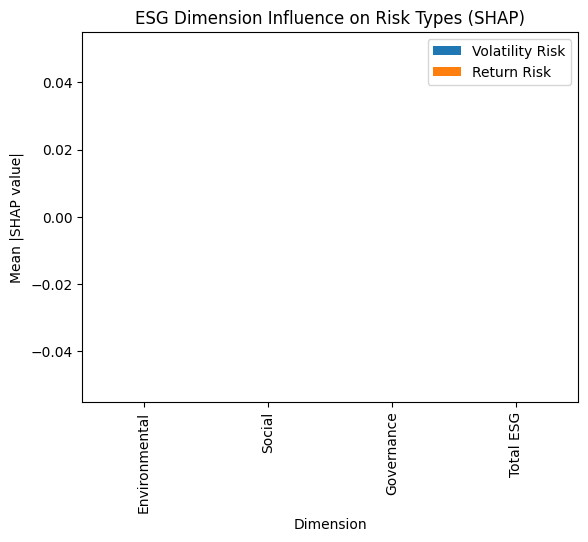

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

dim_df = pd.DataFrame({
    'Dimension': ['Environmental', 'Social', 'Governance', 'Total ESG'],
    'Volatility Risk': [E_vol, S_vol, G_vol, ESG_vol],
    'Return Risk': [E_ret, S_ret, G_ret, ESG_ret]
})

dim_df.set_index('Dimension').plot(kind='bar')
plt.title("ESG Dimension Influence on Risk Types (SHAP)")
plt.ylabel("Mean |SHAP value|")
plt.show()

In [ ]:
print(X_test_v.columns.tolist())
print(X_test_r.columns.tolist())

['esg_risk_score', 'environment_risk_score', 'social_risk_score', 'governance_risk_score', 'controversy_score', 'sector_enc', 'industry_enc']
['esg_risk_score', 'environment_risk_score', 'social_risk_score', 'governance_risk_score', 'controversy_score', 'sector_enc', 'industry_enc']
